### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [180]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [181]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [182]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/marketing_campaign.csv', delimiter='\t')

In [183]:
raw_df = dataset.copy()
raw_df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [184]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**Висновки**

- В датасеті 29 колонок і 2240 рядків

- Пропущенні значення є тільки в колонці `Income` 24 значення

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [185]:
raw_df['Income'].describe(percentiles =[0, 0.25, 0.5, 0.75, 0.995])

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
0%,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
99.5%,102145.750000
max,666666.000000


<Axes: >

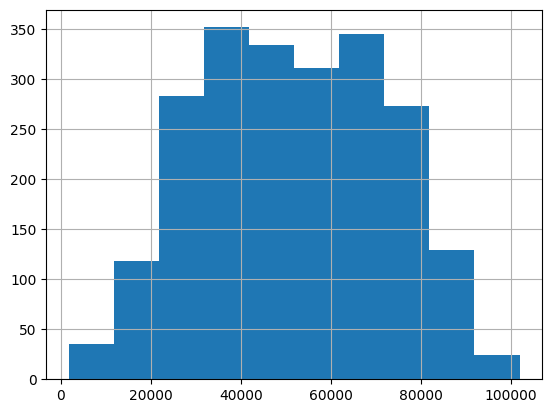

In [186]:
raw_df[raw_df['Income'] < 102145.75]['Income'].hist()

In [187]:
raw_df['Income_missing'] = raw_df['Income'].isna().astype(int)

raw_df['Income'] = raw_df['Income'].fillna(raw_df['Income'].median())

**Висновки**

- В датасеті всього 24 пропущених значення, тому метод імпутаціі не вплине сильно на результат. Я вибрала імпутувати медіаною, бо вона стійка до викидів

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [188]:
raw_df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Income_missing
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,0


In [189]:
from sklearn.preprocessing import OneHotEncoder

def categorical_columns(df):
    df = df.copy()

    df['Marital_Status'] = df['Marital_Status'].replace({
        'Alone': 'Single',
        'YOLO': 'Single',
        'Absurd': 'Single'
    })

    cols = ['Education', 'Marital_Status']

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    encoded = encoder.fit_transform(df[cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(cols),
        index=df.index
    ).round().astype(int)

    return pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [190]:
def features (df):
    df = df.copy()

    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")
    df['Customer_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

    df['Age'] = df['Year_Birth'].max() - df['Year_Birth']

    df['Total_Spent'] = (df['MntWines'] + df['MntFruits'] +
      df['MntMeatProducts'] + df['MntFishProducts'] +
      df['MntSweetProducts'] + df['MntGoldProds'])

    df['Total_Purchases'] = (df['NumWebPurchases'] +
        df['NumCatalogPurchases'] + df['NumStorePurchases'])

    df = df.drop(columns=['Dt_Customer', 'Year_Birth'])

    return df

In [191]:
def preprocess_data(df):
    df = df.drop(columns=['ID'])
    df = categorical_columns(df)
    df = features(df)
    return df

**Висновки**

- Категоріальні змінні були перетворені за допомогою One-Hot Encoding

- Колонка з датою була трансформована у кількість днів з моменту реєстрації клієнта, що є більш інформативно

- Змінна Year_Birth була перетворена у вік клієнта Age, оскільки саме вік є більш інформативним для задачі кластеризації

- Не застосовувала бінінг для ознаки Age, щоб уникнути втрати інформації, алгоритми кластеризації ефективно працюють з числовими ознаками


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [192]:
X = preprocess_data(raw_df)

In [193]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

def train_and_score(df):
  kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
  labels = kmeans.fit_predict(df)
  df['labels'] = labels

  silhouette_metric = silhouette_score(df, labels).round(3)
  print(f"Silhouette score: {silhouette_metric}")

In [194]:
train_and_score(X)

Silhouette score: 0.598


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

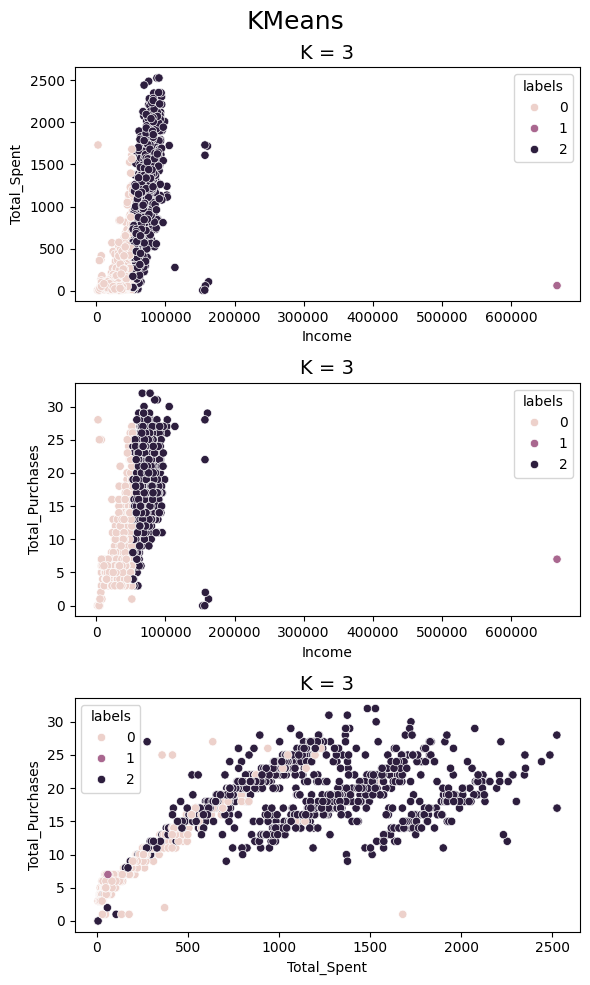

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("KMeans",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Spent", data=X, hue='labels')

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Purchases", data=X, hue='labels')

plt.subplot(3,1,3)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Total_Spent",y="Total_Purchases", data=X, hue='labels')
plt.tight_layout();

In [196]:
import plotly.express as px

fig = px.scatter_3d(
    X,
    x='Income',
    y='Total_Spent',
    z='Total_Purchases',
    color='labels',
    title='Customer Segmentation KMeans'
)

fig.show()


**Висновки**

- Високий silhouette score 0.598 був отриманий через домінування ознаки Income та наявністі викидів. Один із кластерів - 1 викид, що штучно покращує метрику

- Треба поексперементувати з кількістю кластерів

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [197]:
from sklearn.preprocessing import StandardScaler

def scale_data(df):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df)

    return pd.DataFrame(scaled, columns=df.columns, index=df.index)

In [198]:
X_scaled = scale_data(X)

In [199]:
train_and_score(X_scaled)

Silhouette score: 0.13


**Висновки**

- Після застосування StandardScaler silhouette score знизився до 0.13. Це пов’язано з тим, що всі ознаки були приведені до одного масштабу, і модель почала враховувати їх однаково. У результаті кластери стали менш чітко відокремленими, але більш реалістичними

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [200]:
def remove_outliers_iqr(df, cols):
    df = df.copy()

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df


def features_and_outliers (df):
    df = df.copy()

    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")
    df['Customer_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

    df['Age'] = df['Year_Birth'].max() - df['Year_Birth']

    df['Total_Spent'] = (df['MntWines'] + df['MntFruits'] +
        df['MntMeatProducts'] + df['MntFishProducts'] +
        df['MntSweetProducts'] + df['MntGoldProds'])

    df['Total_Purchases'] = (df['NumWebPurchases'] +
        df['NumCatalogPurchases'] + df['NumStorePurchases'])

    cols = ['Age', 'Income' , 'Total_Spent', 'Total_Purchases']
    df = remove_outliers_iqr(df, cols)

    df = df.drop(columns=['Dt_Customer', 'Year_Birth'])

    return df

In [201]:
def preprocess_data_upd(df):
    df = df.drop(columns=['ID'])
    df = categorical_columns(df)
    df = features_and_outliers(df)
    return df

In [202]:
# X without outliers
X_upd = preprocess_data_upd(raw_df)
X_upd  = scale_data(X_upd)

In [203]:
train_and_score(X_upd)

Silhouette score: 0.151


**Висновки**

- Я видалила викиди, значення silhouette score покращилось з 0.13 до 0.151. Це свідчить про те, що обробка викидів дозволила отримати більш компактні кластери

- Незважаючи на покращення метрики, значення silhouette залишається відносно низьким, що свідчить про відсутність чіткої кластерної структури в даних

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

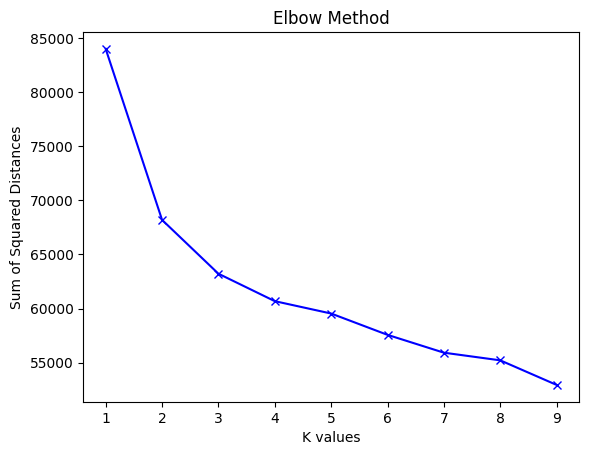

In [204]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_upd)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [205]:
import plotly.express as px

fig = px.scatter_3d(
    X_upd,
    x='Income',
    y='Total_Spent',
    z='Total_Purchases',
    color='labels',
    title='Customer Segmentation KMeans'
)

fig.show()

**Висновки**

- За допомогою Elbow method було визначено оптимальну кількість кластерів k=3

- У порівнянні з попередньою візуалізацію, на ціьому графіку - масштабовані дані без викидів. Отримані кластери менш чітко відокремлені один від одного, але краще відображають когорти клієнтів, які відрізняються рівнем доходу та активністю покупок

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [206]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

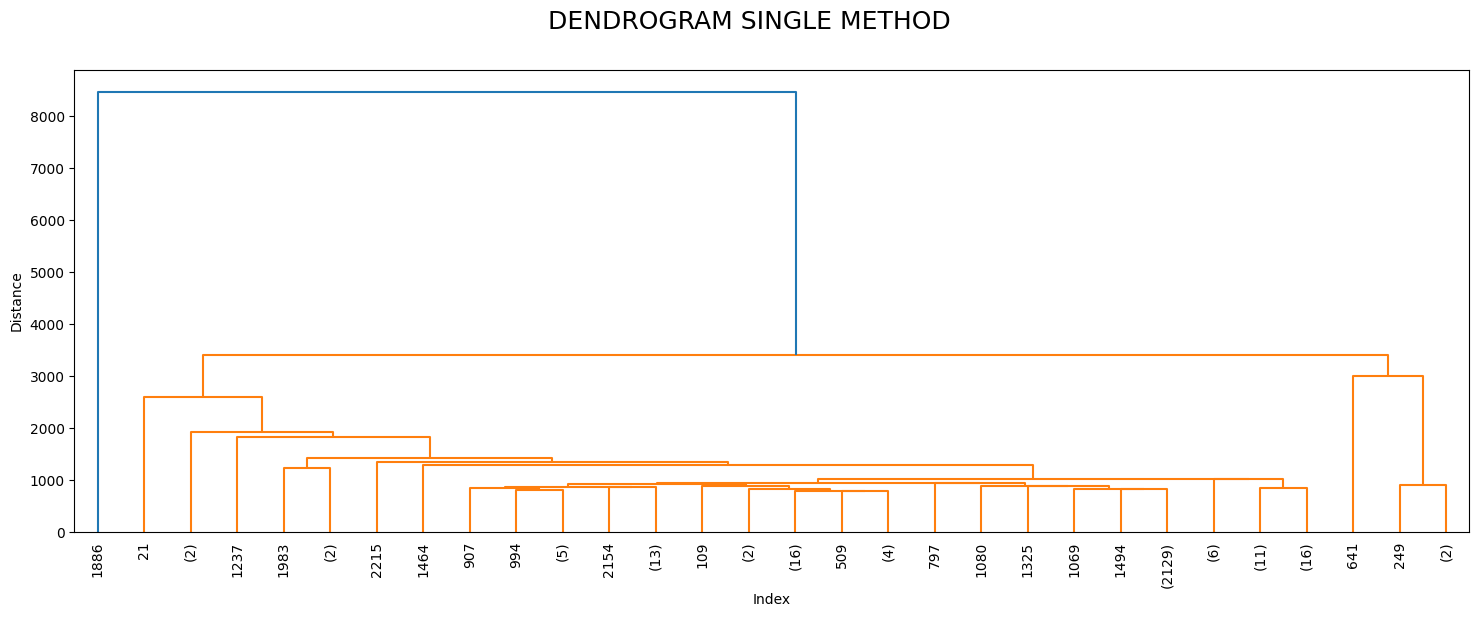

In [207]:
X_without_outliers = preprocess_data_upd(raw_df)

dist_sin = linkage(X_without_outliers, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [208]:
X_without_outliers['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_without_outliers['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

<Axes: title={'center': 'K = 3'}, xlabel='Income', ylabel='Total_Spent'>

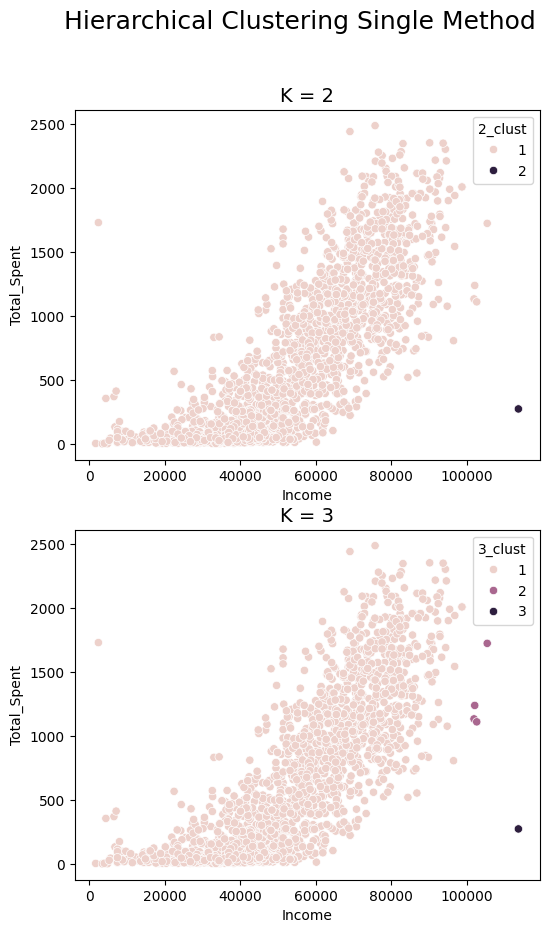

In [209]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(2,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="Total_Spent", data=X_without_outliers, hue="2_clust")

plt.subplot(2,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Spent", data=X_without_outliers, hue="3_clust")


In [210]:
features_for_cluster = X_without_outliers.drop(columns=['2_clust', '3_clust'])

silhouette_k2 = silhouette_score(features_for_cluster, X_without_outliers['2_clust']).round(3)
silhouette_k3 = silhouette_score(features_for_cluster, X_without_outliers['3_clust']).round(3)

print(f"Silhouette score k=2: {silhouette_k2}")
print(f"Silhouette score k=3: {silhouette_k3}")

Silhouette score k=2: 0.559
Silhouette score k=3: 0.452


**Висновки**

 - Метод single linkage показав нестабільні результати кластеризації. Незважаючи на відносно високі значення silhouette score 0.559 та 0.452, візуалізація показує, що більшість точок об'єднуються в один великий кластер, тоді як окремі точки формують малі кластери

- Дана кластеризація не є вдалою, незважаючи на формально високі значення метрики

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [216]:
from sklearn.cluster import DBSCAN

In [248]:
X_dbscan = preprocess_data(raw_df)
X_dbscan  = scale_data(X_dbscan)

In [281]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan.fit(X_dbscan)
labels = dbscan.labels_
print(labels)

[-1 -1 -1 ... -1 -1 -1]


In [282]:
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

mask = labels != -1
s = silhouette_score(X_dbscan[mask], labels[mask])
#s = silhouette_score(X_dbscan, dbscan.labels_)
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.3f}')

Estimated number of clusters: 4
Estimated number of noise points: 2129
Silhouette Coefficient for the data Dataset Clusters: 0.364


In [283]:
fig = px.scatter_3d(
    X_dbscan,
    x='Income',
    y='Total_Spent',
    z='Total_Purchases',
    color=dbscan.labels_,
    title='Customer Segmentation DBSCAN'
)

fig.show()

In [285]:
for eps in [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_dbscan)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        print(f"eps={eps}, min_samples={min_samples} -> clusters={n_clusters}, noise={n_noise}")

eps=0.8, min_samples=5 -> clusters=0, noise=2240
eps=0.8, min_samples=10 -> clusters=0, noise=2240
eps=0.8, min_samples=15 -> clusters=0, noise=2240
eps=1.0, min_samples=5 -> clusters=2, noise=2227
eps=1.0, min_samples=10 -> clusters=0, noise=2240
eps=1.0, min_samples=15 -> clusters=0, noise=2240
eps=1.2, min_samples=5 -> clusters=10, noise=2156
eps=1.2, min_samples=10 -> clusters=0, noise=2240
eps=1.2, min_samples=15 -> clusters=0, noise=2240
eps=1.5, min_samples=5 -> clusters=19, noise=1991
eps=1.5, min_samples=10 -> clusters=4, noise=2129
eps=1.5, min_samples=15 -> clusters=1, noise=2199
eps=1.8, min_samples=5 -> clusters=26, noise=1841
eps=1.8, min_samples=10 -> clusters=7, noise=2031
eps=1.8, min_samples=15 -> clusters=3, noise=2113
eps=2.0, min_samples=5 -> clusters=30, noise=1715
eps=2.0, min_samples=10 -> clusters=10, noise=1952
eps=2.0, min_samples=15 -> clusters=4, noise=2041


**Висновки**

 - Було протестовано алгоритм DBSCAN з різними значеннями eps та min_samples. У більшості випадків алгоритм або не знаходив кластерів зовсім, або визначав надто велику частину спостережень як шум. Це свідчить про відсутність у даних чіткої щільнісної структури, необхідної для ефективної роботи DBSCAN. Тому для цього набору даних DBSCAN виявився менш корисним, ніж KMeans.